# Customer Segmentation (RFM Analysis)
### Goal

Segment customers based on purchasing behavior 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
events=pd.read_csv('events.csv')

In [3]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 116.1 MB


In [4]:
events.describe()

,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


In [5]:
events.isnull().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

In [6]:
events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [7]:
conn=sqlite3.connect('ecommerce.db')

In [8]:
events.to_sql('events',conn,index=False,if_exists='replace')

2756101

# Customer Segmentation using RFM Analysis

## Business Problem

Not all customers contribute equally to business growth.

Some customers purchase frequently and should be retained, while others purchase once and never return.

Using RFM Analysis, we will segment customers into actionable business groups to support retention campaigns, loyalty programs, and personalized marketing.

## RFM Framework

RFM stands for:

- **Recency (R):** How recently did the customer purchase?
- **Frequency (F):** How often does the customer purchase?
- **Monetary (M):** How valuable is the customer?

Since this dataset does not contain transaction values, **purchase count is used as a proxy for Monetary Value**.

In [9]:
#Load the Events Table
query = """SELECT *FROM events"""

events = pd.read_sql(query, conn)

events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [10]:
#buyer table
query = """
SELECT
    visitorid,
    COUNT(*) AS purchases,
    MAX(timestamp) AS last_purchase
FROM events
WHERE event='transaction'
GROUP BY visitorid
"""

buyer_table = pd.read_sql(query, conn)

buyer_table.head()

,visitorid,purchases,last_purchase
0,172,2,1439602141686
1,186,1,1439397297040
2,264,2,1441647285708
3,419,1,1438146192695
4,539,1,1434433178673


In [11]:
buyer_table.shape

(11719, 3)

In [12]:
buyer_table['purchases'].describe()

count    11719.000000
mean         1.916290
std          8.850529
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        559.000000
Name: purchases, dtype: float64

In [13]:
# Last purchase(or latest ) to calculate recency
latest_purchase = pd.read_sql("""
SELECT
    MAX(timestamp) AS latest_purchase
FROM events
WHERE event = 'transaction'
""", conn)

latest_ts = latest_purchase.loc[0, "latest_purchase"]
latest_ts

np.int64(1442544192017)

In [14]:
#Add Recency to buyer_table
buyer_table["recency_days"] = round((latest_ts - buyer_table["last_purchase"]) /(1000 * 60 * 60 * 24),2)

buyer_table.head()

,visitorid,purchases,last_purchase,recency_days
0,172,2,1439602141686,34.05
1,186,1,1439397297040,36.42
2,264,2,1441647285708,10.38
3,419,1,1438146192695,50.90
4,539,1,1434433178673,93.88


In [15]:
buyer_table["recency_days"].describe()

count    11719.000000
mean        70.253264
std         39.089702
min          0.000000
25%         37.245000
50%         70.890000
75%        104.220000
max        137.970000
Name: recency_days, dtype: float64

## Recency Analysis

Recency measures **how recently a customer made their last purchase** and is a key indicator of customer engagement.

### Key Findings

- The dataset contains **11,719 purchasing customers**.
- The **average recency** is **70.25 days**, meaning customers made their last purchase approximately 70 days before the end of the observation period.
- The **median recency** is **70.89 days**, indicating that half of all buyers had not returned for over two months.
- The **most recent customer** purchased on the final day of the dataset (**0 days recency**).
- The **least recent customer** had not made a purchase for **137.97 days**, suggesting a significant group of inactive customers.

### Business Insights

- A large proportion of customers became inactive after their initial purchase, highlighting opportunities for retention and re-engagement campaigns.
- Customers with **low recency values** represent highly engaged shoppers and should be prioritized for loyalty programs and premium offers.
- Customers with **high recency values** are potential churn risks and can be targeted with personalized promotions or win-back campaigns.

R = Recency

F = Purchase Count

M = Purchase Count (Revenue, Price Unavailable)

In [16]:
buyer_table.head()

,visitorid,purchases,last_purchase,recency_days
0,172,2,1439602141686,34.05
1,186,1,1439397297040,36.42
2,264,2,1441647285708,10.38
3,419,1,1438146192695,50.90
4,539,1,1434433178673,93.88


In [17]:
buyer_table.to_sql("buyer_table",conn,index=False,if_exists="replace")

11719

In [18]:
rfm = pd.read_sql("""
WITH rfm_base AS (

SELECT
    visitorid,purchases,last_purchase,recency_days,purchases AS monetary

FROM buyer_table)
select * from rfm_base

""", conn)

rfm.head()

,visitorid,purchases,last_purchase,recency_days,monetary
0,172,2,1439602141686,34.05,2
1,186,1,1439397297040,36.42,1
2,264,2,1441647285708,10.38,2
3,419,1,1438146192695,50.90,1
4,539,1,1434433178673,93.88,1


In [19]:
rfm.to_sql("rfm_base",conn,index=False,if_exists="replace")

11719

In [20]:
rfm_scores=pd.read_sql("""SELECT *,

    6 - NTILE(5) OVER (ORDER BY recency_days) AS R,

    NTILE(5) OVER (ORDER BY purchases) AS F,

    NTILE(5) OVER (ORDER BY monetary) AS M

FROM rfm_base

""", conn)

rfm_scores.head()

,visitorid,purchases,last_purchase,recency_days,monetary,R,F,M
0,152963,349,1442544192017,0.00,349,5,5,5
1,62004,1,1442540841770,0.04,1,5,1,1
2,427756,1,1442541011262,0.04,1,5,2,2
3,355297,1,1442537936041,0.07,1,5,1,1
4,751256,1,1442537989072,0.07,1,5,3,3


In [21]:
rfm_scores[["R","F","M"]].describe()

,R,F,M
count,11719.000000,11719.000000,11719.000000
mean,3.000171,2.999829,2.999829
std,1.414214,1.414214,1.414214
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000


In [22]:
rfm_scores["RFM_Score"] = (rfm_scores["R"].astype(str) +rfm_scores["F"].astype(str) +
    rfm_scores["M"].astype(str))

rfm_scores.head()

,visitorid,purchases,last_purchase,recency_days,monetary,R,F,M,RFM_Score
0,152963,349,1442544192017,0.00,349,5,5,5,555
1,62004,1,1442540841770,0.04,1,5,1,1,511
2,427756,1,1442541011262,0.04,1,5,2,2,522
3,355297,1,1442537936041,0.07,1,5,1,1,511
4,751256,1,1442537989072,0.07,1,5,3,3,533


In [23]:
rfm_scores["FM_Score"] = (rfm_scores["F"] + rfm_scores["M"])

In [24]:
rfm_scores

,visitorid,purchases,last_purchase,recency_days,monetary,R,F,M,RFM_Score,FM_Score
0,152963,349,1442544192017,0.00,349,5,5,5,555,10
1,62004,1,1442540841770,0.04,1,5,1,1,511,2
2,427756,1,1442541011262,0.04,1,5,2,2,522,4
3,355297,1,1442537936041,0.07,1,5,1,1,511,2
4,751256,1,1442537989072,0.07,1,5,3,3,533,6
...,...,...,...,...,...,...,...,...,...,...
11714,266417,2,1430627474950,137.92,2,1,5,5,155,10
11715,435495,1,1430626058961,137.94,1,1,2,2,122,4
11716,586756,1,1430625707591,137.95,1,1,2,2,122,4
11717,345781,1,1430624101772,137.96,1,1,1,1,111,2


In [25]:
# segments
conditions = [(rfm_scores["R"] >= 4) & (rfm_scores["FM_Score"] >= 8),

    (rfm_scores["R"] >= 3) & (rfm_scores["FM_Score"] >= 6),

    (rfm_scores["R"] >= 4) & (rfm_scores["FM_Score"] <= 5),

    (rfm_scores["R"] <= 2) & (rfm_scores["FM_Score"] >= 6),

    (rfm_scores["R"] <= 2) & (rfm_scores["FM_Score"] <= 5)]

segments = ["Champions","Loyal Customers","Potential Loyalists","At Risk","Lost Customers"]

rfm_scores["Segment"] = np.select(conditions,segments,default="Needs Attention")

rfm_scores.head()

,visitorid,purchases,last_purchase,recency_days,monetary,R,F,M,RFM_Score,FM_Score,Segment
0,152963,349,1442544192017,0.00,349,5,5,5,555,10,Champions
1,62004,1,1442540841770,0.04,1,5,1,1,511,2,Potential Loyalists
2,427756,1,1442541011262,0.04,1,5,2,2,522,4,Potential Loyalists
3,355297,1,1442537936041,0.07,1,5,1,1,511,2,Potential Loyalists
4,751256,1,1442537989072,0.07,1,5,3,3,533,6,Loyal Customers


In [26]:
rfm_scores["Segment"].value_counts()

Segment
At Risk                2778
Loyal Customers        2353
Lost Customers         1909
Champions              1900
Potential Loyalists    1853
Needs Attention         926
Name: count, dtype: int64

In [27]:
segment_summary = rfm_scores["Segment"].value_counts().reset_index()

segment_summary.columns = ["Segment","Customers"]

segment_summary["Percentage"] = round(segment_summary["Customers"] /segment_summary["Customers"].sum()*100,2)

segment_summary

,Segment,Customers,Percentage
0,At Risk,2778,23.71
1,Loyal Customers,2353,20.08
2,Lost Customers,1909,16.29
3,Champions,1900,16.21
4,Potential Loyalists,1853,15.81
5,Needs Attention,926,7.90


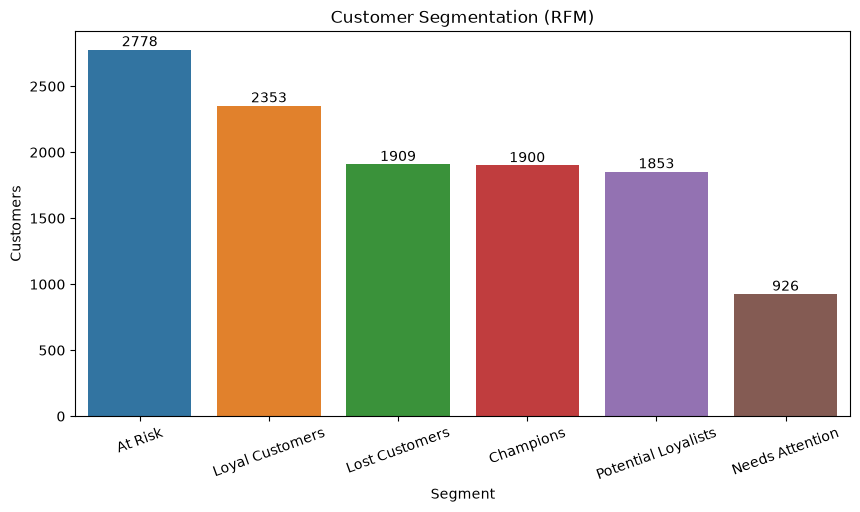

In [28]:
#plot
plt.figure(figsize=(10,5))

ax=sns.barplot(data=segment_summary,x="Segment",y="Customers",hue="Segment",legend=False)

plt.title("Customer Segmentation (RFM)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)
plt.savefig('Customer Segmentation (RFM).png',dpi=400)
plt.show()

# Customer Segmentation (RFM Analysis)

Customers were segmented using the **RFM (Recency, Frequency, Monetary)** framework based on:

- **Recency:** Days since the customer's last purchase.
- **Frequency:** Total number of purchases.
- **Monetary (Proxy):** Number of unique products purchased, used as a proxy for customer value because transaction revenue is unavailable.

## Segment Distribution

| Segment | Customers | Percentage |
|----------|----------:|-----------:|
| At Risk | 2,778 | 23.71% |
| Loyal Customers | 2,353 | 20.08% |
| Lost Customers | 1,909 | 16.29% |
| Champions | 1,900 | 16.21% |
| Potential Loyalists | 1,853 | 15.81% |
| Needs Attention | 926 | 7.90% |

## Key Business Insights

- **At Risk** customers form the largest segment (**23.71%**), indicating a significant number of previously active customers have not purchased recently and should be prioritized for retention campaigns.
- **Loyal Customers (20.08%)** represent a strong and stable customer base that consistently purchases and should be rewarded through loyalty programs and personalized offers.
- **Champions (16.21%)** are the platform's highest-value customers, combining recent activity with strong purchasing behavior. These customers should receive VIP treatment, exclusive promotions, and early product access.
- **Potential Loyalists (15.81%)** have recently engaged with the platform and show strong potential to become long-term loyal customers through targeted engagement campaigns.
- **Lost Customers (16.29%)** have low recent activity and low engagement, making them suitable candidates for win-back campaigns or reactivation strategies.
- **Needs Attention (7.90%)** is the smallest segment, representing customers with moderate engagement who require timely interventions before they transition into the At Risk category.

## Business Recommendations

| Segment | Recommended Action |
|----------|--------------------|
| Champions | VIP rewards, early access, premium support |
| Loyal Customers | Loyalty points, referral programs, cross-selling |
| Potential Loyalists | Personalized recommendations and targeted promotions |
| Needs Attention | Limited-time offers and engagement reminders |
| At Risk | Win-back campaigns, discounts, retention emails |
| Lost Customers | Reactivation campaigns and customer feedback surveys |